# libMesh, Z88, Abaqus results and OpenRadioss

Four FEM formats added in v16.7.0:

- **libMesh `.xda`/`.xdr`** is the native mesh file of [libMesh](https://libmesh.github.io/) and MOOSE: one stream of values, as ASCII or as big-endian XDR, holding the refinement tree, subdomains and boundary sets.
- **Z88** is an open-source FEM program for teaching and small companies. Its structure file has a fixed name, `z88i1.txt`, and its results sit beside it as `z88o2.txt` (displacements) and `z88o3.txt` (stresses).
- **The Abaqus results file (`.fil`)** is what `*NODE FILE` and `*EL FILE` write: the one route into Abaqus results that needs neither the ODB API nor an Abaqus install.
- **The OpenRadioss starter deck (`*_0000.rad`)** is the explicit solver's own input format: fixed-width `/KEYWORD` blocks with parts, groups and surfaces.

All four are read by both engines; Z88 is also written. The files are in `tests/python/meshes/`: decks written from each format's documentation, Z88R's own output for one of them, and real Abaqus 2023 results from pybaqus (MIT).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4')]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## libMesh: one stream, two encodings

`hex27.xda` and `hex27.xdr` hold the same two HEX27 elements, once as text and once as XDR. The subdomains become cell regions (one named by the file's map, one not), the side sets side regions, and the node set a point region. libMesh lists the vertical mid-edge nodes of a HEX27 before the top ring; they are reordered on read.

ASCII == XDR: True
libMesh-1.3.0
2	 # number of elements
45	 # number of nodes
.	 # boundary condition specification file
.	 # subdomain id specification file
n/a	 # processor id specification file

wall         point tag 5: 9 entries
left         cell  tag 1: 1 entries
subdomain_2  cell  tag 2: 1 entries
boundary_2   side  tag 2: 1 entries
inlet        side  tag 1: 1 entries


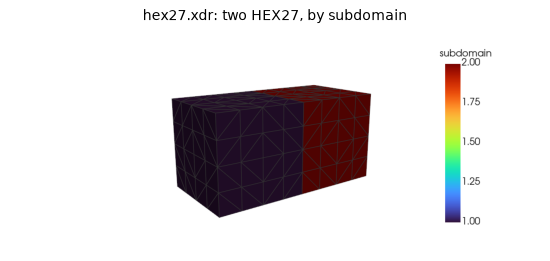

In [2]:
text = mp.read(path('libmesh', 'hex27.xda'))
binary = mp.read(path('libmesh', 'hex27.xdr'))
print('ASCII == XDR:', np.array_equal(text.points, binary.points) and
      np.array_equal(text.cells[0].data, binary.cells[0].data))
with open(path('libmesh', 'hex27.xda')) as fh:
    print(''.join(fh.readlines()[:6]))
for r in text.regions:
    print(f'{r.name:12s} {r.kind:5s} tag {r.tag}: {len(r.entries)} entries')
gallery([(curved(to_grid(text, cell_data={'subdomain': text.cell_data['libmesh:subdomain']}), 2), 'subdomain',
          'hex27.xdr: two HEX27, by subdomain', None)], ncols=1, size=(1000, 420))

libMesh keeps the whole refinement tree in the file. Only its leaves are cells: `amr_quad.xdr` holds one quadrilateral refined into four, so four cells come out, with their level and p-level. The boundary condition sits on the coarse element's bottom edge, and is carried down to the two children whose edges lie on it. An unused node id (NaN coordinates in the file) is dropped.

<meshio++ mesh object>
  Number of points: 9
  Number of cells:
    quad: 4
  Cell sets: subdomain_0
  Side sets: bottom
  Point data: libmesh:id
  Cell data: libmesh:level, libmesh:p_level, libmesh:subdomain
side region bottom -> [[0, 0], [1, 0]] (cell, local edge)
p-levels: [1 1 2 0] | kept node ids: [0 1 2 3 4 5 6 7 8]


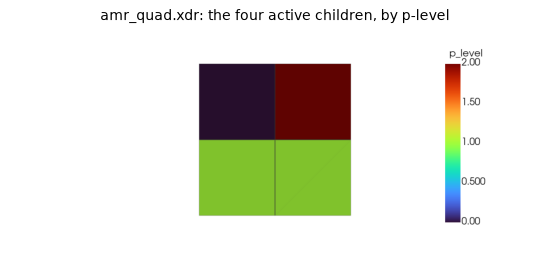

In [3]:
amr = mp.read(path('libmesh', 'amr_quad.xdr'))
print(amr)
bottom = next(r for r in amr.regions if r.kind == 'side')
print('side region', bottom.name, '->', bottom.entries.tolist(), '(cell, local edge)')
print('p-levels:', amr.cell_data['libmesh:p_level'][0], '| kept node ids:', amr.point_data['libmesh:id'])
gallery([(to_grid(amr, cell_data={'p_level': amr.cell_data['libmesh:p_level']}), 'p_level',
          'amr_quad.xdr: the four active children, by p-level', None)], ncols=1, size=(1000, 420), view=(0, 0, 1))

## Z88: a cantilever and Z88R's results

`cantilever/z88i1.txt` is a 100 × 10 × 10 beam of five 20-node hexahedra, clamped at one end and loaded at the other. Its `z88o2.txt` and `z88o3.txt` are Z88R V15's own output for it. The file name picks the format, although `.txt` is otherwise the xyz reader's, and the results next to it are attached: the displacements as `U`, each element's mean stress as `SIG` and `SIGV`.

<meshio++ mesh object>
  Number of points: 68
  Number of cells:
    hexahedron20: 5
  Point data: U
  Cell data: SIG, SIGV, z88:type
tip deflection -1.8487 mm (Euler-Bernoulli: -1.9048)


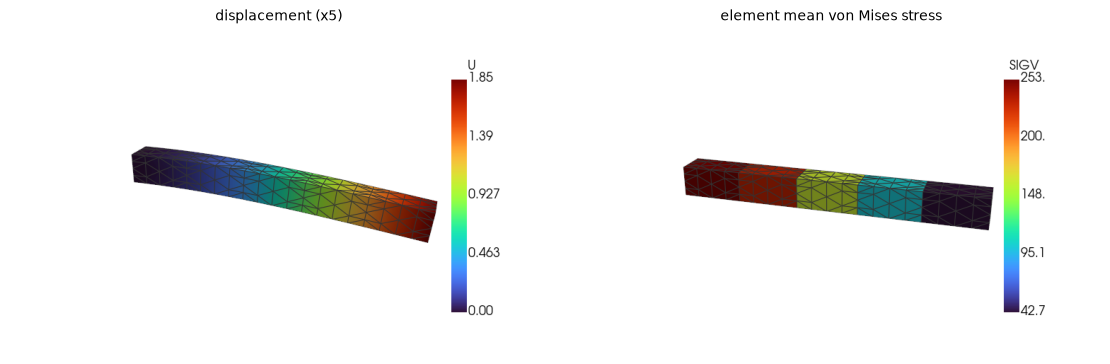

In [4]:
beam = mp.read(path('z88/cantilever', 'z88i1.txt'))
print(beam)
tip = beam.point_data['U'][np.isclose(beam.points[:, 0], 100.0), 2].min()
print(f'tip deflection {tip:.4f} mm (Euler-Bernoulli: {-1000 * 100**3 / (3 * 210000 * 10**4 / 12):.4f})')
grid = to_grid(beam, point_data={'U': beam.point_data['U']}, cell_data={'SIGV': beam.cell_data['SIGV']})
warped = grid.warp_by_vector('U', factor=5.0)
gallery([(curved(warped, 2), 'U', 'displacement (x5)', None),
         (curved(grid, 2), 'SIGV', 'element mean von Mises stress', None)], ncols=2, view=(0.3, -1.0, 0.4))

Z88's hexahedra list the face the manual draws on top first, so read as they are their volume is negative; the `"z88"` node-order table turns them over. The writer applies the inverse, and Z88R solves the deck meshio++ writes back to the same displacements. A 2-D plate with the older Z88 header and a deck in cylindrical coordinates read too:

['z88i1.txt', 'z88i2.txt', 'z88i5.txt']
    3        68         5         204     0   Written by meshio++ v16.6.0
        1  3 +0.0000000000000000E+00 +0.0000000000000000E+00 +1.0000000000000000E+01
        2  3 +2.0000000000000000E+01 +0.0000000000000000E+00 +1.0000000000000000E+01



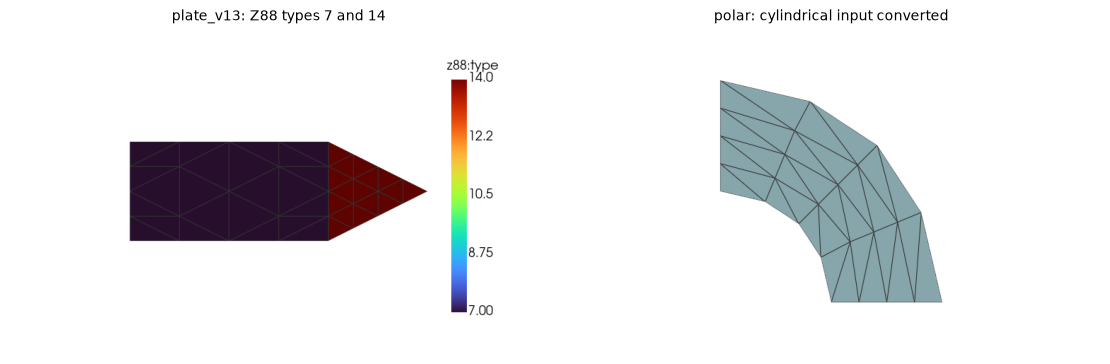

In [5]:
out_dir = os.path.join(TMP, 'z88')
os.makedirs(out_dir)
mp.z88.write(os.path.join(out_dir, 'z88i1.txt'), mp.z88.read(path('z88/cantilever', 'z88i1.txt'), results=False), stubs=True)
print(sorted(os.listdir(out_dir)))
with open(os.path.join(out_dir, 'z88i1.txt')) as fh:
    print(''.join(fh.readlines()[:3]))
plate = mp.read(path('z88/plate_v13', 'z88i1.txt'))
polar = mp.read(path('z88/polar', 'z88i1.txt'))
gallery([(curved(to_grid(plate, cell_data={'z88:type': plate.cell_data['z88:type']}), 2), 'z88:type', 'plate_v13: Z88 types 7 and 14', None),
         (curved(to_grid(polar), 2), None, 'polar: cylindrical input converted', None)], ncols=2, view=(0, 0, 1))

## Abaqus `.fil`: increments as steps

`model.fil` is a synthetic ASCII results file, written record by record from the Abaqus guide, and `model_le.fil`/`model_be.fil` the same records in binary, little- and big-endian. Every increment is a step. Stresses at the integration points come out as `(cells, points, components)` arrays, a shell's section points as separate arrays (`S`, `S@sp5`), and nodal records as point data. The three encodings read to the same mesh and values.

increments: [0.5, 1.0]
<meshio++ mesh object>
  Number of points: 24
  Number of cells:
    hexahedron20: 1
    hexahedron: 1
    quad: 1
  Point sets: ASSEMBLY_PART-1-1_CLAMPED_NODES
  Cell sets: SOLIDS
  Point data: PEEQ, RF, U, abaqus:id
  Cell data: E, NFORC, S, S@sp5, SINV, abaqus:id
  Field data: abaqus:increment, abaqus:procedure, abaqus:step, abaqus:step_time, meshio:time
{'E': [(1, 8, 6), (1, 1, 6), (1, 1, 6)], 'NFORC': [(1, 20, 3), (1, 8, 3), (1, 4, 3)], 'S': [(1, 8, 6), (1, 1, 6), (1, 1, 3)], 'S@sp5': [(1, 1, 3), (1, 1, 3), (1, 1, 3)], 'SINV': [(1, 7), (1, 7), (1, 7)]}
model_le.fil U as the ASCII file: True
model_be.fil U as the ASCII file: True
sequence steps (time, mesh): [(0.5, 24), (1.0, 24)]


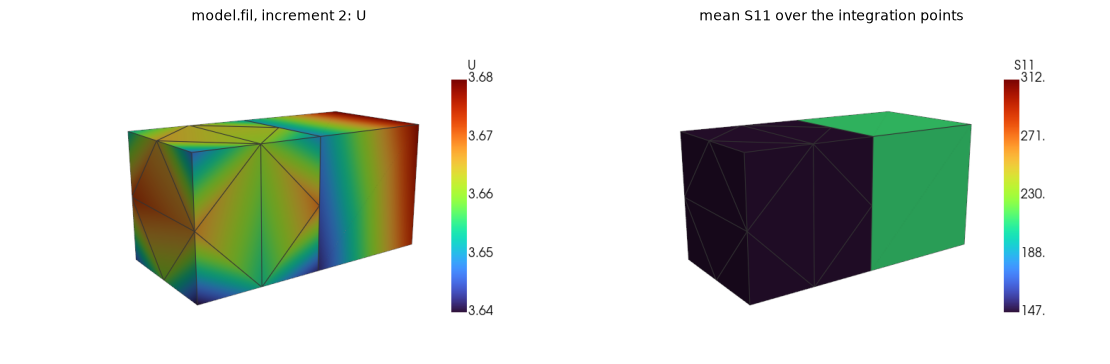

In [6]:
fil = path('abaqus_fil', 'model.fil')
print('increments:', mp.abaqus_fil.time_values(fil))
last = mp.read(fil, time_step=-1)
print(last)
print({name: [a.shape for a in blocks] for name, blocks in last.cell_data.items() if name != 'abaqus:id'})
for name in ('model_le.fil', 'model_be.fil'):
    other = mp.read(path('abaqus_fil', name), time_step=-1)
    print(name, 'U as the ASCII file:', np.allclose(other.point_data['U'], last.point_data['U'], rtol=1e-15))
steps = list(mp.read_sequence(fil))
print('sequence steps (time, mesh):', [(float(t), len(m.points)) for t, m in steps])
s_mean = [np.nanmean(b.reshape(len(b), -1, b.shape[-1])[..., 0], axis=1) for b in last.cell_data['S']]
gallery([(to_grid(last, point_data={'U': last.point_data['U']}), 'U', 'model.fil, increment 2: U', None),
         (to_grid(last, cell_data={'S11': s_mean}), 'S11', 'mean S11 over the integration points', None)], ncols=2)

`pybaqus/hex_C3D8.fil` is real Abaqus 2023 output from pybaqus's test suite: one C3D8 element under a load. Its sets are named through Abaqus's label cross-references (long assembly names are stored as numbers). The values match pybaqus's own reading; the shear components are reordered from Abaqus's 12, 13, 23 to meshio++'s xy, yz, zx.

In [7]:
real = mp.read(path('abaqus_fil/pybaqus', 'hex_C3D8.fil'))
print(real)
print('S at the first integration point:', np.round(real.cell_data['S'][0][0, 0], 4))
# S is (cells, integration points, 6): average it per cell, then take von Mises.
real.cell_data['S_mean'] = [block.mean(axis=1) for block in real.cell_data['S']]
mises = mp.tensor_invariants(real, location='cell', keys=['S_mean'], outputs=['mises'])
print({k: np.round(v[0], 3) for k, v in mises.cell_data.items() if k.startswith('S_mean')})

<meshio++ mesh object>
  Number of points: 8
  Number of cells:
    hexahedron: 1
  Point sets: ASSEMBLY_SET_BC_1, ASSEMBLY_SET_BC_2, ASSEMBLY_SET_BC_3, ASSEMBLY_SET_LOAD, ASSEMBLY_TEST_INSTANCE_SET-TEST_PART
  Cell sets: ASSEMBLY_TEST_INSTANCE_SET-TEST_PART
  Point data: COORD, U, abaqus:id
  Cell data: COORD, E, S, abaqus:id
  Field data: abaqus:increment, abaqus:procedure, abaqus:step, abaqus:step_time, meshio:time
S at the first integration point: [-1.7818  6.6953  3.4199 23.5246 52.6371  3.3907]
{'S_mean': array([[ 1.667,  6.667,  0.   ,  3.333, 20.   ,  0.   ]]), 'S_mean_mises': array([35.629])}


## OpenRadioss: parts, groups and surfaces

`deck_0000.rad` is a synthetic starter deck with one element of every card the reader reads: bricks (some with repeated nodes, which are tetrahedra, pyramids and wedges), a 20-node brick, 10- and 4-node tetrahedra, a penta, shells, beams, trusses and springs. Each `/PART` is a cell region named by its title; `/GRNOD`, `/GRBRIC`, `/GRSHEL` groups and `/SURF/SEG` surfaces become point, cell and side regions. The deck `#include`s a second file.

<meshio++ mesh object>
  Number of points: 88
  Number of cells:
    line: 4
    hexahedron: 1
    wedge: 3
    tetra: 2
    pyramid: 1
    hexahedron20: 1
    tetra10: 1
    quad: 1
    triangle: 2
  Point sets: hex nodes, quadratic nodes, skin nodes
  Cell sets: Part 4, bricks, in a box, included truss, part 2 solids, quad shell, quadratic, quadratic subset, shells, solid parts, some bricks, subset solids, union
  Side sets: skin
  Cell data: radioss:material, radioss:part, radioss:property
  Field data: radioss:version
hex nodes          point tag  1: 8 entries
quadratic nodes    point tag  2: 40 entries
skin nodes         point tag  9: 11 entries
Part 4             cell  tag  4: 3 entries
bricks             cell  tag  1: 5 entries
in a box           cell  tag  8: 0 entries
included truss     cell  tag  5: 1 entries
part 2 solids      cell  tag  4: 4 entries
quad shell         cell  tag  5: 1 entries
quadratic          cell  tag  2: 4 entries
quadratic subset   cell  tag  2: 7 entri

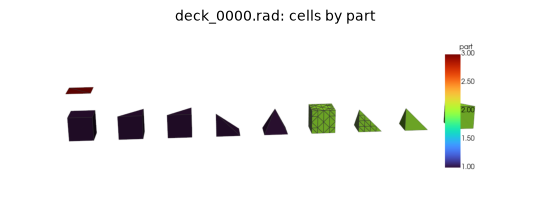

In [8]:
deck = mp.read(path('radioss', 'deck_0000.rad'))
print(deck)
for r in deck.regions:
    print(f'{r.name:18s} {r.kind:5s} tag {r.tag:2d}: {len(r.entries)} entries')
parts = np.concatenate(deck.cell_data['radioss:part'])
blocks = [c for c in deck.cells if c.type != 'line']
gallery([(curved(to_grid(deck, cell_data={'part': deck.cell_data['radioss:part']}), 2), 'part',
          'deck_0000.rad: cells by part', None)], ncols=1, size=(1400, 420), view=(-0.1, -1.0, 0.3), zoom=2.6)

## What was checked

- **libMesh:** libMesh (LGPL) is not a dependency. The reader was run on libMesh's own sample meshes: every element type in both encodings, the reference elements, and a refined mesh with boundary sets. Every cell has a positive volume and every higher-order node sits where meshio++'s tables put it.
- **Z88:** the 14 example decks of Z88OS read in both engines with positive volumes, and Z88R solved the fixture deck and the deck meshio++ writes back to the same displacements. No Z88Aurora file was available.
- **Abaqus `.fil`:** no Abaqus licence was available. The reader matches pybaqus on all 236 displacement and stress values of its real Abaqus 2023 files, and reads a 16 MB binary file with nine increments. A comparison with a run's `.dat` printout is still to do.
- **OpenRadioss:** the 81 starter decks of OpenRadioss's QA suite (not redistributable) read in both engines with positive volumes. Units are not applied.

See the [libMesh](../../doc/formats/libmesh.md), [Z88](../../doc/formats/z88.md), [Abaqus `.fil`](../../doc/formats/abaqus_fil.md) and [Radioss](../../doc/formats/radioss.md) pages.